In [1]:
import warnings
warnings.filterwarnings('ignore')

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import f_oneway, pearsonr, chi2_contingency

In [5]:
taxi_df=pd.read_csv('Taxi_Trip_Data.csv')
taxi_df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1.0,01/01/2020 12:28:15 AM,01/01/2020 12:33:03 AM,1.0,1.20,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.00,0.3,11.27,2.5
1,1.0,01/01/2020 12:35:39 AM,01/01/2020 12:43:04 AM,1.0,1.20,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.00,0.3,12.30,2.5
2,1.0,01/01/2020 12:47:41 AM,01/01/2020 12:53:52 AM,1.0,0.60,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.00,0.3,10.80,2.5
3,1.0,01/01/2020 12:55:23 AM,01/01/2020 01:00:14 AM,1.0,0.80,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.00,0.3,8.16,0.0
4,2.0,01/01/2020 12:01:58 AM,01/01/2020 12:04:16 AM,1.0,0.00,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.00,0.3,4.80,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6499995,2.0,02/01/2020 12:52:43 PM,02/01/2020 01:02:11 PM,1.0,1.21,1.0,N,238,239,1.0,7.5,0.0,0.5,2.16,0.00,0.3,14.91,2.5
6499996,2.0,02/01/2020 12:38:19 PM,02/01/2020 01:19:03 PM,1.0,17.77,2.0,N,132,100,1.0,52.0,0.0,0.5,12.28,6.12,0.3,73.70,2.5
6499997,2.0,02/01/2020 12:12:39 PM,02/01/2020 12:25:20 PM,1.0,3.57,1.0,N,13,33,1.0,13.5,0.0,0.5,3.36,0.00,0.3,20.16,2.5
6499998,2.0,02/01/2020 12:42:47 PM,02/01/2020 01:09:27 PM,1.0,5.85,1.0,N,209,230,2.0,23.5,0.0,0.5,0.00,0.00,0.3,26.80,2.5


In [6]:
taxi_df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1.0,01/01/2020 12:28:15 AM,01/01/2020 12:33:03 AM,1.0,1.2,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5
1,1.0,01/01/2020 12:35:39 AM,01/01/2020 12:43:04 AM,1.0,1.2,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5
2,1.0,01/01/2020 12:47:41 AM,01/01/2020 12:53:52 AM,1.0,0.6,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5
3,1.0,01/01/2020 12:55:23 AM,01/01/2020 01:00:14 AM,1.0,0.8,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0
4,2.0,01/01/2020 12:01:58 AM,01/01/2020 12:04:16 AM,1.0,0.0,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0


In [7]:
taxi_df.tail()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
6499995,2.0,02/01/2020 12:52:43 PM,02/01/2020 01:02:11 PM,1.0,1.21,1.0,N,238,239,1.0,7.5,0.0,0.5,2.16,0.00,0.3,14.91,2.5
6499996,2.0,02/01/2020 12:38:19 PM,02/01/2020 01:19:03 PM,1.0,17.77,2.0,N,132,100,1.0,52.0,0.0,0.5,12.28,6.12,0.3,73.70,2.5
6499997,2.0,02/01/2020 12:12:39 PM,02/01/2020 12:25:20 PM,1.0,3.57,1.0,N,13,33,1.0,13.5,0.0,0.5,3.36,0.00,0.3,20.16,2.5
6499998,2.0,02/01/2020 12:42:47 PM,02/01/2020 01:09:27 PM,1.0,5.85,1.0,N,209,230,2.0,23.5,0.0,0.5,0.00,0.00,0.3,26.80,2.5
6499999,2.0,02/01/2020 12:02:24 PM,02/01/2020 12:13:36 PM,4.0,1.89,1.0,N,142,236,1.0,9.5,0.0,0.5,2.56,0.00,0.3,15.36,2.5


In [9]:
taxi_df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge'],
      dtype='object')

In [10]:
taxi_df.dtypes

VendorID                 float64
tpep_pickup_datetime      object
tpep_dropoff_datetime     object
passenger_count          float64
trip_distance            float64
RatecodeID               float64
store_and_fwd_flag        object
PULocationID               int64
DOLocationID               int64
payment_type             float64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
congestion_surcharge     float64
dtype: object

In [11]:
#  Drop duplicates
taxi_df.drop_duplicates(inplace=True)

In [12]:
taxi_df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1.0,01/01/2020 12:28:15 AM,01/01/2020 12:33:03 AM,1.0,1.20,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.00,0.3,11.27,2.5
1,1.0,01/01/2020 12:35:39 AM,01/01/2020 12:43:04 AM,1.0,1.20,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.00,0.3,12.30,2.5
2,1.0,01/01/2020 12:47:41 AM,01/01/2020 12:53:52 AM,1.0,0.60,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.00,0.3,10.80,2.5
3,1.0,01/01/2020 12:55:23 AM,01/01/2020 01:00:14 AM,1.0,0.80,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.00,0.3,8.16,0.0
4,2.0,01/01/2020 12:01:58 AM,01/01/2020 12:04:16 AM,1.0,0.00,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.00,0.3,4.80,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6499995,2.0,02/01/2020 12:52:43 PM,02/01/2020 01:02:11 PM,1.0,1.21,1.0,N,238,239,1.0,7.5,0.0,0.5,2.16,0.00,0.3,14.91,2.5
6499996,2.0,02/01/2020 12:38:19 PM,02/01/2020 01:19:03 PM,1.0,17.77,2.0,N,132,100,1.0,52.0,0.0,0.5,12.28,6.12,0.3,73.70,2.5
6499997,2.0,02/01/2020 12:12:39 PM,02/01/2020 12:25:20 PM,1.0,3.57,1.0,N,13,33,1.0,13.5,0.0,0.5,3.36,0.00,0.3,20.16,2.5
6499998,2.0,02/01/2020 12:42:47 PM,02/01/2020 01:09:27 PM,1.0,5.85,1.0,N,209,230,2.0,23.5,0.0,0.5,0.00,0.00,0.3,26.80,2.5


In [14]:
#Convert datetime columns
taxi_df['tpep_pickup_datetime'] = pd.to_datetime(taxi_df['tpep_pickup_datetime'], errors='coerce')
taxi_df['tpep_pickup_datetime']

0         2020-01-01 00:28:15
1         2020-01-01 00:35:39
2         2020-01-01 00:47:41
3         2020-01-01 00:55:23
4         2020-01-01 00:01:58
                  ...        
6499995   2020-02-01 12:52:43
6499996   2020-02-01 12:38:19
6499997   2020-02-01 12:12:39
6499998   2020-02-01 12:42:47
6499999   2020-02-01 12:02:24
Name: tpep_pickup_datetime, Length: 6487051, dtype: datetime64[ns]

In [24]:
taxi_df['tpep_dropoff_datetime'] = pd.to_datetime(taxi_df['tpep_dropoff_datetime'], errors='coerce')
taxi_df['tpep_dropoff_datetime']

0         2020-01-01 00:33:03
1         2020-01-01 00:43:04
2         2020-01-01 00:53:52
3         2020-01-01 01:00:14
4         2020-01-01 00:04:16
                  ...        
6499995   2020-02-01 13:02:11
6499996   2020-02-01 13:19:03
6499997   2020-02-01 12:25:20
6499998   2020-02-01 13:09:27
6499999   2020-02-01 12:13:36
Name: tpep_dropoff_datetime, Length: 6487051, dtype: datetime64[ns]

In [33]:
#Cleaning the numeric columns
numeric_cols = [
    'VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'payment_type',
    'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount',
    'improvement_surcharge', 'total_amount', 'congestion_surcharge'
]
taxi_df[numeric_cols] = taxi_df[numeric_cols].apply(pd.to_numeric, errors='coerce')
taxi_df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.20,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.00,0.3,11.27,2.5
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.20,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.00,0.3,12.30,2.5
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.60,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.00,0.3,10.80,2.5
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.80,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.00,0.3,8.16,0.0
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.00,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.00,0.3,4.80,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6499995,2.0,2020-02-01 12:52:43,2020-02-01 13:02:11,1.0,1.21,1.0,N,238,239,1.0,7.5,0.0,0.5,2.16,0.00,0.3,14.91,2.5
6499996,2.0,2020-02-01 12:38:19,2020-02-01 13:19:03,1.0,17.77,2.0,N,132,100,1.0,52.0,0.0,0.5,12.28,6.12,0.3,73.70,2.5
6499997,2.0,2020-02-01 12:12:39,2020-02-01 12:25:20,1.0,3.57,1.0,N,13,33,1.0,13.5,0.0,0.5,3.36,0.00,0.3,20.16,2.5
6499998,2.0,2020-02-01 12:42:47,2020-02-01 13:09:27,1.0,5.85,1.0,N,209,230,2.0,23.5,0.0,0.5,0.00,0.00,0.3,26.80,2.5


In [42]:
#Handling the invalid values
taxi_df = taxi_df[
    (taxi_df['trip_distance'] >= 0) &
    (taxi_df['fare_amount'] >= 0) &
    (taxi_df['total_amount'] >= 0) &
    (taxi_df['passenger_count'] > 0)
]
taxi_df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.20,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.00,0.3,11.27,2.5
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.20,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.00,0.3,12.30,2.5
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.60,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.00,0.3,10.80,2.5
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.80,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.00,0.3,8.16,0.0
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.00,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.00,0.3,4.80,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6499995,2.0,2020-02-01 12:52:43,2020-02-01 13:02:11,1.0,1.21,1.0,N,238,239,1.0,7.5,0.0,0.5,2.16,0.00,0.3,14.91,2.5
6499996,2.0,2020-02-01 12:38:19,2020-02-01 13:19:03,1.0,17.77,2.0,N,132,100,1.0,52.0,0.0,0.5,12.28,6.12,0.3,73.70,2.5
6499997,2.0,2020-02-01 12:12:39,2020-02-01 12:25:20,1.0,3.57,1.0,N,13,33,1.0,13.5,0.0,0.5,3.36,0.00,0.3,20.16,2.5
6499998,2.0,2020-02-01 12:42:47,2020-02-01 13:09:27,1.0,5.85,1.0,N,209,230,2.0,23.5,0.0,0.5,0.00,0.00,0.3,26.80,2.5


In [45]:
#Removing the rows with missing critical values
critical_cols = ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'VendorID', 'total_amount']
taxi_df.dropna(subset=critical_cols, inplace=True)
taxi_df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.20,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.00,0.3,11.27,2.5
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.20,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.00,0.3,12.30,2.5
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.60,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.00,0.3,10.80,2.5
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.80,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.00,0.3,8.16,0.0
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.00,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.00,0.3,4.80,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6499995,2.0,2020-02-01 12:52:43,2020-02-01 13:02:11,1.0,1.21,1.0,N,238,239,1.0,7.5,0.0,0.5,2.16,0.00,0.3,14.91,2.5
6499996,2.0,2020-02-01 12:38:19,2020-02-01 13:19:03,1.0,17.77,2.0,N,132,100,1.0,52.0,0.0,0.5,12.28,6.12,0.3,73.70,2.5
6499997,2.0,2020-02-01 12:12:39,2020-02-01 12:25:20,1.0,3.57,1.0,N,13,33,1.0,13.5,0.0,0.5,3.36,0.00,0.3,20.16,2.5
6499998,2.0,2020-02-01 12:42:47,2020-02-01 13:09:27,1.0,5.85,1.0,N,209,230,2.0,23.5,0.0,0.5,0.00,0.00,0.3,26.80,2.5


In [54]:
taxi_df.rename(columns={
    'tpep_pickup_datetime': 'pickup_datetime',
    'tpep_dropoff_datetime': 'dropoff_datetime',
    'PULocationID': 'pickup_location_id',
    'DOLocationID': 'dropoff_location_id'
}, inplace=True)
taxi_df

,VendorID,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,pickup_location_id,dropoff_location_id,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.20,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.00,0.3,11.27,2.5
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.20,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.00,0.3,12.30,2.5
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.60,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.00,0.3,10.80,2.5
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.80,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.00,0.3,8.16,0.0
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.00,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.00,0.3,4.80,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6499995,2.0,2020-02-01 12:52:43,2020-02-01 13:02:11,1.0,1.21,1.0,N,238,239,1.0,7.5,0.0,0.5,2.16,0.00,0.3,14.91,2.5
6499996,2.0,2020-02-01 12:38:19,2020-02-01 13:19:03,1.0,17.77,2.0,N,132,100,1.0,52.0,0.0,0.5,12.28,6.12,0.3,73.70,2.5
6499997,2.0,2020-02-01 12:12:39,2020-02-01 12:25:20,1.0,3.57,1.0,N,13,33,1.0,13.5,0.0,0.5,3.36,0.00,0.3,20.16,2.5
6499998,2.0,2020-02-01 12:42:47,2020-02-01 13:09:27,1.0,5.85,1.0,N,209,230,2.0,23.5,0.0,0.5,0.00,0.00,0.3,26.80,2.5


In [58]:
#Checking the missing values in each column
missing_values = taxi_df.isnull().sum()
missing_values

VendorID                 0
pickup_datetime          0
dropoff_datetime         0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
pickup_location_id       0
dropoff_location_id      0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
dtype: int64

In [59]:
#Checking for the duplicate records
duplicate_count = taxi_df.duplicated().sum()
duplicate_count

0

In [65]:
#Creating a new column for trip duration in minutes
taxi_df['trip_duration_min'] = (taxi_df['dropoff_datetime'] - taxi_df['pickup_datetime']).dt.total_seconds() / 60
taxi_df['trip_duration_min']

0           4.800000
1           7.416667
2           6.183333
3           4.850000
4           2.300000
             ...    
6499995     9.466667
6499996    40.733333
6499997    12.683333
6499998    26.666667
6499999    11.200000
Name: trip_duration_min, Length: 6285239, dtype: float64

In [77]:
# What are the peak hours for pickups and drop-offs?
# Extracting pickup and dropoff hours
taxi_df['pickup_hour'] = taxi_df['pickup_datetime'].dt.hour
taxi_df['dropoff_hour'] = taxi_df['dropoff_datetime'].dt.hour

In [81]:
# Count of pickups and drop-offs by hour
pickup_counts_by_hour = taxi_df['pickup_hour'].value_counts().sort_index()
dropoff_counts_by_hour = taxi_df['dropoff_hour'].value_counts().sort_index()

In [88]:
#Which days of the week and time of day see the highest number of trips?
# Extracting the day of week and hour
taxi_df['pickup_day'] = taxi_df['pickup_datetime'].dt.day_name()
taxi_df['pickup_hour'] = taxi_df['pickup_datetime'].dt.hour

# Grouping by day of  the week
trips_by_day = taxi_df['pickup_day'].value_counts()

# Grouping by both day and hour
trips_by_day_hour = taxi_df.groupby(['pickup_day', 'pickup_hour']).size()
trips_by_day_hour 

pickup_day  pickup_hour
Friday      0              25610
            1              15229
            2               9183
            3               6320
            4               5735
                           ...  
Wednesday   19             63085
            20             58435
            21             59836
            22             49550
            23             31611
Length: 168, dtype: int64

In [91]:
# Grouping by pickup day
avg_duration_by_day = taxi_df.groupby('pickup_day')['trip_duration_min'].mean()
avg_duration_by_day

pickup_day
Friday       16.419046
Monday       15.491176
Saturday     15.465663
Sunday       15.335643
Thursday     16.373397
Tuesday      15.596592
Wednesday    16.033732
Name: trip_duration_min, dtype: float64

In [93]:
#Has the number of trips changed over the month (January vs February)?
# Extracting the month name
taxi_df['pickup_month'] = taxi_df['pickup_datetime'].dt.month_name()
taxi_df['pickup_month']

0           January
1           January
2           January
3           January
4           January
             ...   
6499995    February
6499996    February
6499997    February
6499998    February
6499999    February
Name: pickup_month, Length: 6285239, dtype: object

In [94]:
# Counting the trips per month
trips_by_month = taxi_df['pickup_month'].value_counts()
trips_by_month

pickup_month
January     6205861
February      79189
December        139
July             38
March             5
May               5
April             1
June              1
Name: count, dtype: int64

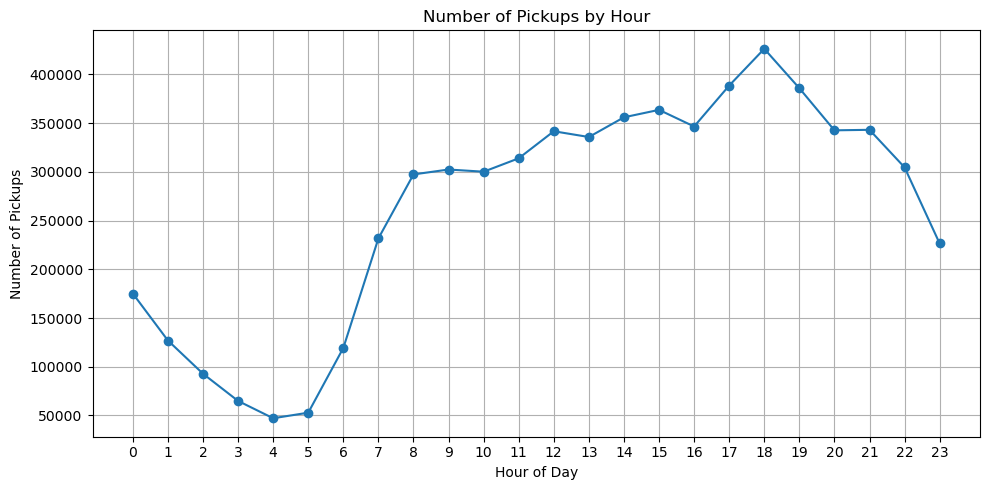

In [99]:
#Pickups per Hour
import matplotlib.pyplot as plt

pickup_counts_by_hour = taxi_df['pickup_hour'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.plot(pickup_counts_by_hour.index, pickup_counts_by_hour.values, marker='o')
plt.title('Number of Pickups by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Pickups')
plt.grid(True)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

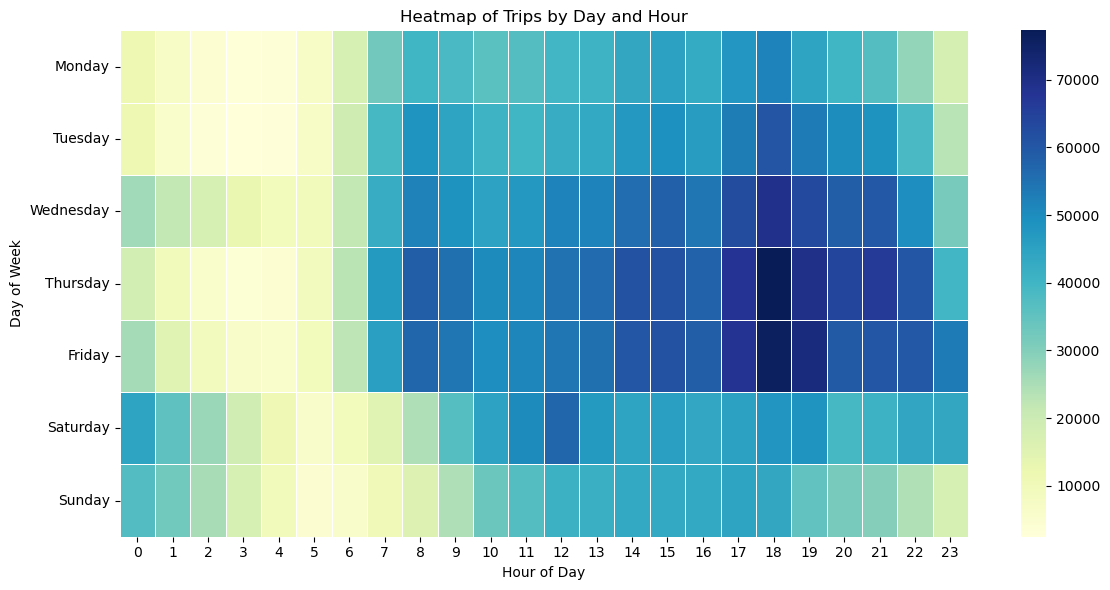

In [129]:
#Number of Trips by Day of Week and Hour
import seaborn as sns
import pandas as pd

# Creating a pivot table
heatmap_data = taxi_df.groupby(['pickup_day', 'pickup_hour']).size().unstack()


day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(day_order)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='YlGnBu', linewidths=0.5)
plt.title('Heatmap of Trips by Day and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()


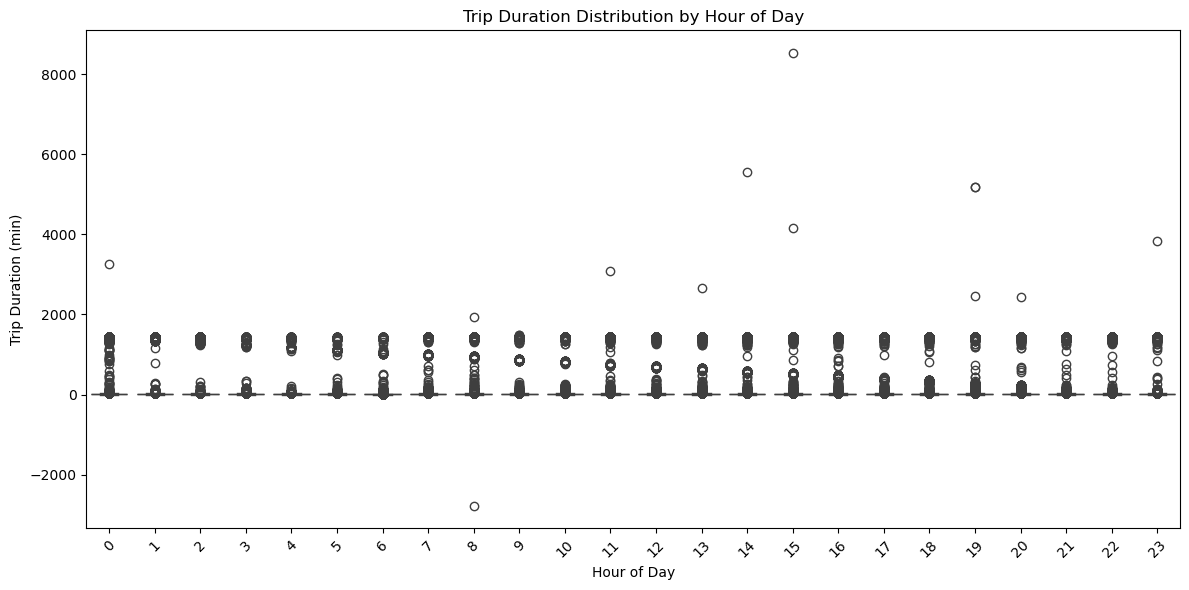

In [133]:
#Trip Duration by Hour
plt.figure(figsize=(12, 6))
sns.boxplot(x='pickup_hour', y='trip_duration_min', data=taxi_df)
plt.title('Trip Duration Distribution by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Trip Duration (min)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

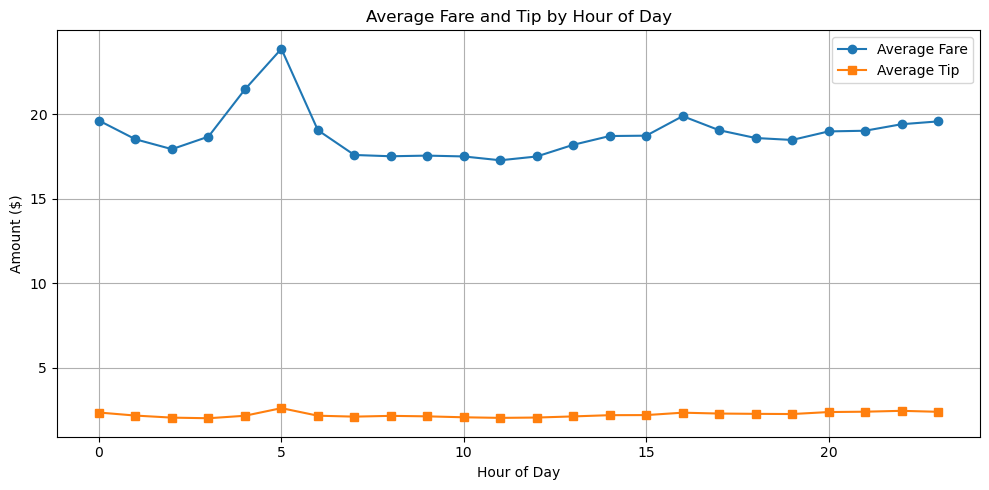

In [146]:
#Line Chart for Fare/Tip by Hour
# Average fare and tip by hour
avg_fare_by_hour = taxi_df.groupby('pickup_hour')['total_amount'].mean()
avg_tip_by_hour = taxi_df.groupby('pickup_hour')['tip_amount'].mean()

plt.figure(figsize=(10, 5))
plt.plot(avg_fare_by_hour.index, avg_fare_by_hour.values, label='Average Fare', marker='o')
plt.plot(avg_tip_by_hour.index, avg_tip_by_hour.values, label='Average Tip', marker='s')
plt.title('Average Fare and Tip by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Amount ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [150]:
# Average Fare, Tip, and Total per Passenger Count
passenger_avg = taxi_df.groupby('passenger_count')[['fare_amount', 'tip_amount', 'total_amount']].mean().reset_index()
passenger_avg

,passenger_count,fare_amount,tip_amount,total_amount
0,1.0,12.453867,2.218754,18.435376
1,2.0,13.041903,2.238302,19.148122
2,3.0,12.814609,2.166128,18.813703
3,4.0,13.292741,2.074251,19.224723
4,5.0,12.265039,2.221835,18.281620
5,6.0,12.372858,2.234488,18.394210
6,7.0,62.008276,6.552759,71.143103
7,8.0,49.745882,4.960000,58.197059
8,9.0,69.770526,7.793158,81.244211


In [153]:
#Most Frequent Passenger Count
most_common_passenger_count = taxi_df['passenger_count'].value_counts().idxmax()
most_common_passenger_count

1.0

In [156]:
taxi_df['passenger_count'].value_counts()

passenger_count
1.0    4589615
2.0     956013
3.0     252799
5.0     228285
6.0     133769
4.0     124693
7.0         29
9.0         19
8.0         17
Name: count, dtype: int64

In [159]:
#Do Multi-Passenger Trips Yield Higher Tips or Totals?
taxi_df['is_multi_passenger'] = taxi_df['passenger_count'] >= 2

multi_passenger_avg = taxi_df.groupby('is_multi_passenger')[['tip_amount', 'total_amount']].mean().reset_index()
multi_passenger_avg

,is_multi_passenger,tip_amount,total_amount
0,False,2.218754,18.435376
1,True,2.213123,18.929738


In [164]:
#Vendor Comparison for Fare and Tip
vendor_stats = taxi_df.groupby('VendorID')[['fare_amount', 'tip_amount']].mean().reset_index()
vendor_stats

,VendorID,fare_amount,tip_amount
0,1.0,12.227777,2.120643
1,2.0,12.724957,2.262471


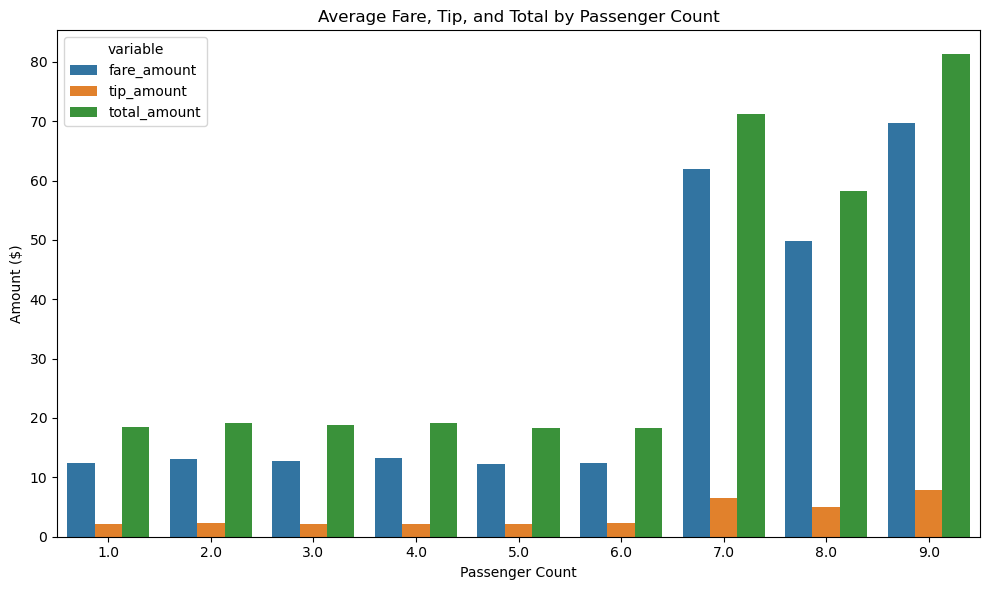

In [174]:
#Bar Plot for  Average Fare, Tip, Total by Passenger Count
plt.figure(figsize=(10, 6))
passenger_avg_melted = passenger_avg.melt(id_vars='passenger_count', value_vars=['fare_amount', 'tip_amount', 'total_amount'])

sns.barplot(x='passenger_count', y='value', hue='variable', data=passenger_avg_melted)
plt.title('Average Fare, Tip, and Total by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Amount ($)')
plt.tight_layout()
plt.show()

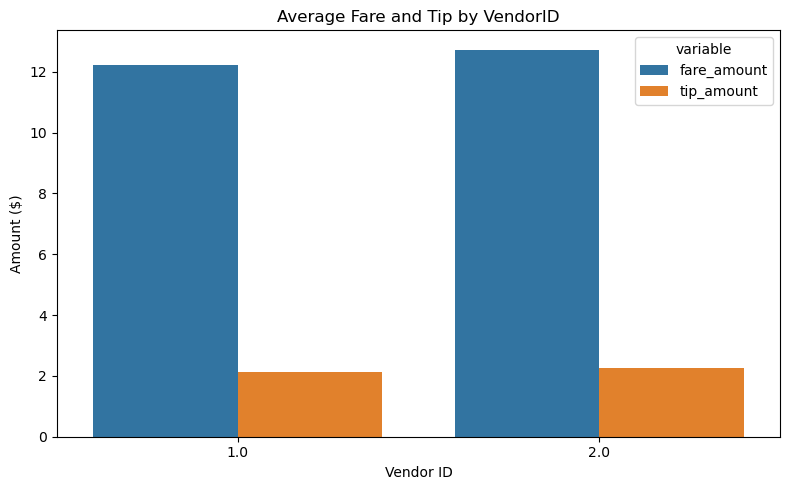

In [184]:
#Bar Plot for VendorID Comparison
plt.figure(figsize=(8, 5))
vendor_stats_melted = vendor_stats.melt(id_vars='VendorID', value_vars=['fare_amount', 'tip_amount'])

sns.barplot(x='VendorID', y='value', hue='variable', data=vendor_stats_melted)
plt.title('Average Fare and Tip by VendorID')
plt.xlabel('Vendor ID')
plt.ylabel('Amount ($)')
plt.tight_layout()
plt.show()

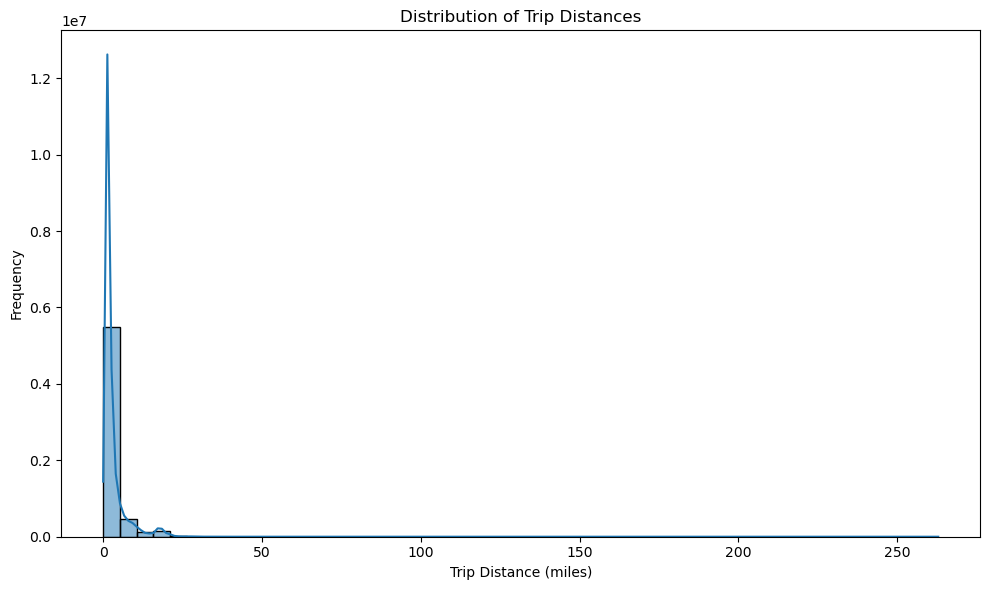

In [198]:
#Distribution of Trip Distance
plt.figure(figsize=(10, 6))
sns.histplot(taxi_df['trip_distance'], bins=50, kde=True)
plt.title("Distribution of Trip Distances")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [212]:
#Pickup & Drop-off Pairs with Longest/Shortest Average Trip Distance
location_pairs = taxi_df.groupby(['pickup_location_id', 'dropoff_location_id'])['trip_distance'].mean().reset_index()
location_pairs

,pickup_location_id,dropoff_location_id,trip_distance
0,1,1,0.682152
1,1,50,16.070000
2,1,68,16.190000
3,1,138,28.330000
4,1,140,1.700000
...,...,...,...
26497,265,259,2.310000
26498,265,261,18.100000
26499,265,263,2.545000
26500,265,264,0.134662


In [214]:
longest_trips = location_pairs.sort_values(by='trip_distance', ascending=False).head(5)
longest_trips

,pickup_location_id,dropoff_location_id,trip_distance
26409,265,39,61.420000
14455,150,265,52.745000
20516,220,68,52.260000
482,9,44,48.653333
17645,181,265,47.173333


In [219]:
shortest_trips = location_pairs[location_pairs['trip_distance'] > 0].sort_values(by='trip_distance').head(5)
shortest_trips

,pickup_location_id,dropoff_location_id,trip_distance
2081,29,264,0.001429
11503,131,264,0.002857
19351,207,207,0.003244
19418,208,264,0.003333
1269,17,264,0.003333


In [230]:
#Pearson Correlation Coefficient (PCC)
pcc_fare = pearsonr(taxi_df['trip_distance'], taxi_df['fare_amount'])
pcc_fare

PearsonRResult(statistic=0.8579717440794093, pvalue=0.0)

In [226]:
pcc_total = pearsonr(taxi_df['trip_distance'], taxi_df['total_amount'])
pcc_total

PearsonRResult(statistic=0.8601105802482716, pvalue=0.0)

In [228]:
pcc_tip = pearsonr(taxi_df['trip_distance'], taxi_df['tip_amount'])
pcc_tip

PearsonRResult(statistic=0.525747966611827, pvalue=0.0)

In [229]:
pcc_duration = pearsonr(taxi_df['trip_distance'], taxi_df['trip_duration_min'])
pcc_duration

PearsonRResult(statistic=0.13396039482817546, pvalue=0.0)

In [242]:
# ANOVA: Trip Distance vs Fare Category
group1 = taxi_df[taxi_df['fare_amount'] <= 10]['trip_distance']
group2 = taxi_df[(taxi_df['fare_amount'] > 10) & (taxi_df['fare_amount'] <= 20)]['trip_distance']
group3 = taxi_df[(taxi_df['fare_amount'] > 20) & (taxi_df['fare_amount'] <= 30)]['trip_distance']
group4 = taxi_df[(taxi_df['fare_amount'] > 30) & (taxi_df['fare_amount'] <= 50)]['trip_distance']
group5 = taxi_df[(taxi_df['fare_amount'] > 50) & (taxi_df['fare_amount'] <= 100)]['trip_distance']
group6 = taxi_df[taxi_df['fare_amount'] > 100]['trip_distance']
anova_result = f_oneway(group1, group2, group3, group4, group5, group6)
anova_result

F_onewayResult(statistic=4441285.8514551, pvalue=0.0)

In [271]:
taxi_df['distance_group'] = np.where(taxi_df['trip_distance'] <= 2, '0-2',
                            np.where(taxi_df['trip_distance'] <= 5, '2-5',
                            np.where(taxi_df['trip_distance'] <= 10, '5-10',
                            np.where(taxi_df['trip_distance'] <= 20, '10-20',
                            np.where(taxi_df['trip_distance'] <= 50, '20-50', '50+')))))
contingency = pd.crosstab(taxi_df['distance_group'], taxi_df['passenger_count'])
chi2_result = chi2_contingency(contingency)
chi2_result

Chi2ContingencyResult(statistic=2846.7890389569293, pvalue=0.0, dof=40, expected_freq=array([[2.81306121e+06, 5.85958319e+05, 1.54945254e+05, 7.64266810e+04,
        1.39920163e+05, 8.19895319e+04, 1.77746445e+01, 1.04196192e+01,
        1.16454568e+01],
       [2.18160897e+05, 4.54427340e+04, 1.20164451e+04, 5.92710646e+03,
        1.08512065e+04, 6.35852136e+03, 1.37847423e+00, 8.08071101e-01,
        9.03138290e-01],
       [1.17382261e+06, 2.44506276e+05, 6.46549179e+04, 3.18910110e+04,
        5.83853098e+04, 3.42122545e+04, 7.41693053e+00, 4.34785583e+00,
        4.85936828e+00],
       [2.93731493e+04, 6.11840265e+03, 1.61789230e+03, 7.98024693e+02,
        1.46100476e+03, 8.56110329e+02, 1.85597556e-01, 1.08798568e-01,
        1.21598399e-01],
       [3.54928414e+05, 7.39312944e+04, 1.95496895e+04, 9.64287608e+03,
        1.76539498e+04, 1.03447498e+04, 2.24265521e+00, 1.31465995e+00,
        1.46932583e+00],
       [2.68721415e+02, 5.59744481e+01, 1.48013515e+01, 7.30076040e+0

In [275]:
#How do fare, tip, and total vary by payment type?
payment_summary = taxi_df.groupby('payment_type')[['fare_amount', 'tip_amount', 'total_amount']].mean()
payment_summary

,fare_amount,tip_amount,total_amount
payment_type,,,
1.0,12.731863,2.983832,19.589969
2.0,12.068144,0.000182,15.599272
3.0,12.775674,0.003992,16.113956
4.0,13.750028,0.001533,17.156394
5.0,0.000000,0.000000,0.000000


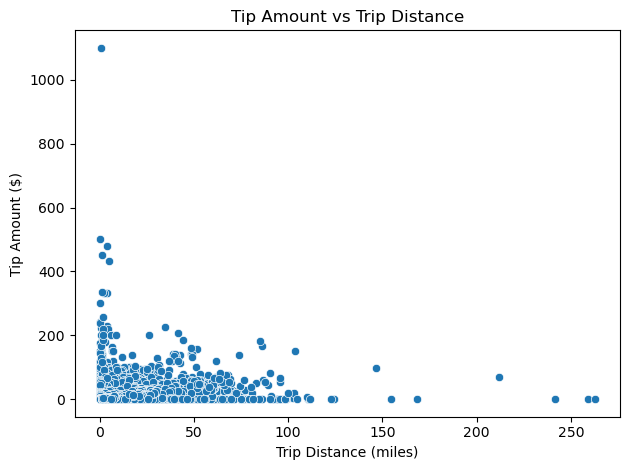

In [284]:
sns.scatterplot(data=taxi_df, x='trip_distance', y='tip_amount')
plt.title('Tip Amount vs Trip Distance')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Tip Amount ($)')
plt.tight_layout()
plt.show()

In [289]:
#Do trips with congestion surcharge have higher tips?
taxi_df['has_congestion'] = taxi_df['congestion_surcharge'] > 0
tip_by_congestion = taxi_df.groupby('has_congestion')['tip_amount'].mean()
tip_by_congestion

has_congestion
False    2.640616
True     2.182921
Name: tip_amount, dtype: float64

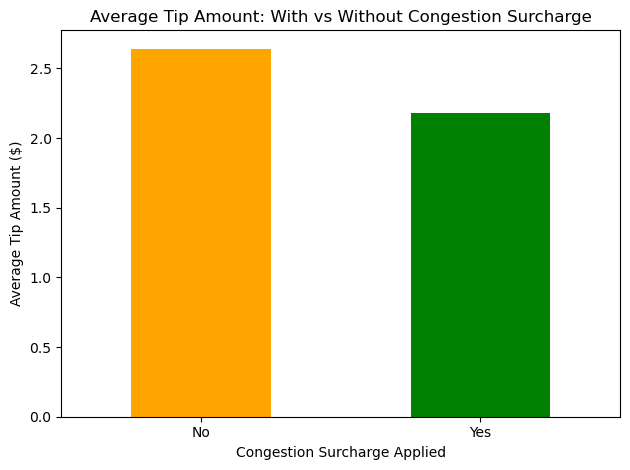

In [298]:
tip_by_congestion.plot(kind='bar', color=['orange', 'green'])
plt.title('Average Tip Amount: With vs Without Congestion Surcharge')
plt.xlabel('Congestion Surcharge Applied')
plt.ylabel('Average Tip Amount ($)')
plt.xticks([0,1], ['No', 'Yes'], rotation=0)
plt.tight_layout()
plt.show()

In [304]:
#Frequency of each payment_type and RatecodeID
payment_type_counts = taxi_df['payment_type'].value_counts()
payment_type_counts

payment_type
1.0    4670322
2.0    1582000
3.0      24206
4.0       8710
5.0          1
Name: count, dtype: int64

In [309]:
ratecode_counts = taxi_df['RatecodeID'].value_counts()
ratecode_counts

RatecodeID
1.0     6076249
2.0      155147
5.0       35272
3.0       13185
4.0        5083
99.0        261
6.0          42
Name: count, dtype: int64

In [315]:
#Do RatecodeID categories affect total_amount or tip_amount?
ratecode_summary = taxi_df.groupby('RatecodeID')[['tip_amount', 'total_amount']].mean()
ratecode_summary 

,tip_amount,total_amount
RatecodeID,,
1.0,1.997700,16.757594
2.0,8.604254,69.244556
3.0,10.349961,88.877704
4.0,8.408113,87.478263
5.0,8.023977,71.445382
6.0,2.392857,36.842857
99.0,0.295747,17.329847


In [320]:
# Does RatecodeID 2 (JFK) or 5 (Group Ride) result in higher fares?
jfk_group = taxi_df[(taxi_df['RatecodeID'] == 2) | (taxi_df['RatecodeID'] == 5)]
jfk_vs_group = jfk_group.groupby('RatecodeID')['fare_amount'].mean()

In [322]:
taxi_df.columns

Index(['VendorID', 'pickup_datetime', 'dropoff_datetime', 'passenger_count',
       'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'pickup_location_id', 'dropoff_location_id', 'payment_type',
       'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount',
       'improvement_surcharge', 'total_amount', 'congestion_surcharge',
       'trip_duration_min', 'pickup_hour', 'dropoff_hour', 'pickup_day',
       'pickup_month', 'is_multi_passenger', 'distance_group',
       'tip_to_fare_ratio', 'has_congestion'],
      dtype='object')

In [327]:
#Which locations have the most pickups and drop-offs?
pickup_counts = taxi_df['pickup_location_id'].value_counts()
dropoff_counts = taxi_df['dropoff_location_id'].value_counts()

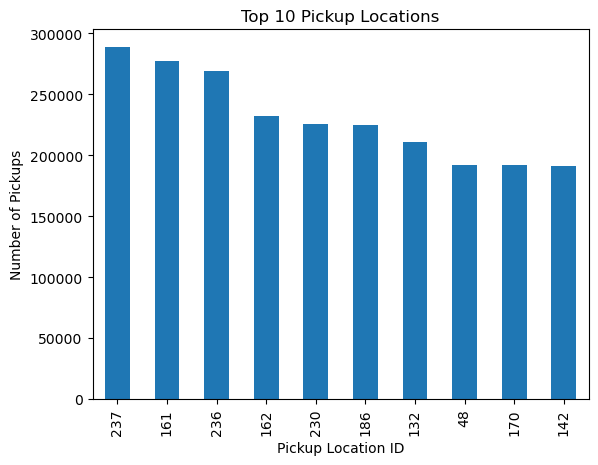

In [328]:
pickup_counts.head(10).plot(kind='bar', title='Top 10 Pickup Locations')
plt.xlabel('Pickup Location ID')
plt.ylabel('Number of Pickups')
plt.show()

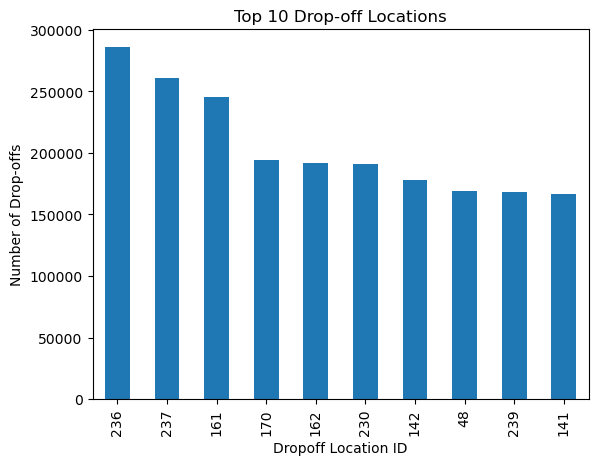

In [329]:
dropoff_counts.head(10).plot(kind='bar', title='Top 10 Drop-off Locations')
plt.xlabel('Dropoff Location ID')
plt.ylabel('Number of Drop-offs')
plt.show()

In [337]:
# What are the most common pickup-drop pairs?
taxi_df['pickup_drop_pair'] = (
    taxi_df['pickup_location_id'].astype(str) + '-' + taxi_df['dropoff_location_id'].astype(str)
)
pair_counts = taxi_df['pickup_drop_pair'].value_counts()
pair_counts

pickup_drop_pair
237-236    44980
236-236    38116
236-237    37898
237-237    33246
264-264    27504
           ...  
127-149        1
40-151         1
210-86         1
226-136        1
51-38          1
Name: count, Length: 26502, dtype: int64

In [341]:
#Do certain pickup locations consistently have longer or costlier trips?
pickup_analysis = taxi_df.groupby('pickup_location_id')[['trip_distance', 'total_amount']].mean()
pickup_analysis

,trip_distance,total_amount
pickup_location_id,,
1,0.795666,100.248438
2,7.200000,25.563333
3,6.481429,37.810429
4,2.619877,17.703915
5,18.239231,61.225641
...,...,...
261,4.121481,22.845913
262,2.284245,16.015746
263,2.053640,15.022798


In [342]:
# Congestion surcharge variation across time/day
congestion_by_hour = taxi_df.groupby('pickup_hour')['congestion_surcharge'].mean()
congestion_by_hour

pickup_hour
0     2.270382
1     2.299229
2     2.310054
3     2.270313
4     2.181410
5     2.077092
6     2.216980
7     2.268697
8     2.304797
9     2.329616
10    2.332414
11    2.347702
12    2.336270
13    2.322331
14    2.313817
15    2.306053
16    2.302376
17    2.319154
18    2.334630
19    2.336861
20    2.322894
21    2.327825
22    2.319277
23    2.287366
Name: congestion_surcharge, dtype: float64

In [343]:
congestion_by_day = taxi_df.groupby('pickup_day')['congestion_surcharge'].mean()
congestion_by_day

pickup_day
Friday       2.316521
Monday       2.290173
Saturday     2.325259
Sunday       2.284467
Thursday     2.322702
Tuesday      2.322322
Wednesday    2.313767
Name: congestion_surcharge, dtype: float64

In [346]:
#Trend in trips with extras or tolls
extras_by_month = taxi_df.groupby('pickup_month')['extra'].sum()
extras_by_month

pickup_month
April             0.00
December         68.00
February      71180.50
January     6668164.81
July              6.00
June              0.00
March             1.00
May               0.00
Name: extra, dtype: float64

In [347]:
tolls_by_month = taxi_df.groupby('pickup_month')['tolls_amount'].sum()
tolls_by_month

pickup_month
April             0.00
December         36.72
February      18311.79
January     2091471.87
July              0.00
June              0.00
March             0.00
May               0.00
Name: tolls_amount, dtype: float64

In [348]:
#Trips with high improvement surcharges
high_improvement = taxi_df.groupby('pickup_location_id')['improvement_surcharge'].mean()
high_improvement

pickup_location_id
1      0.297554
2      0.300000
3      0.291429
4      0.299763
5      0.300000
         ...   
261    0.299867
262    0.299894
263    0.299908
264    0.297328
265    0.297502
Name: improvement_surcharge, Length: 260, dtype: float64

In [349]:
# Top 10 pickup locations with highest improvement surcharge
high_improvement = high_improvement.sort_values(ascending=False).head(10)
high_improvement

pickup_location_id
109    0.3
58     0.3
67     0.3
118    0.3
119    0.3
248    0.3
187    0.3
189    0.3
60     0.3
59     0.3
Name: improvement_surcharge, dtype: float64

In [351]:
#Do surcharges impact tips or total amount?
# Correlation between congestion surcharge and tip amount
congestion_tip_corr = taxi_df['congestion_surcharge'].corr(taxi_df['tip_amount'])
congestion_tip_corr

-0.04369240089882751

In [353]:
# Correlation between congestion surcharge and total amount
congestion_total_corr = taxi_df['congestion_surcharge'].corr(taxi_df['total_amount'])
congestion_total_corr

-0.19678057032270282

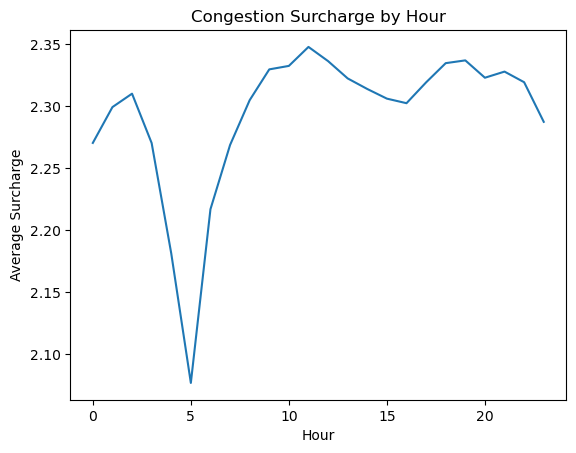

In [357]:
# Congestion surcharge by hour
congestion_by_hour.plot(kind='line', title='Congestion Surcharge by Hour')
plt.xlabel('Hour')
plt.ylabel('Average Surcharge')
plt.show()

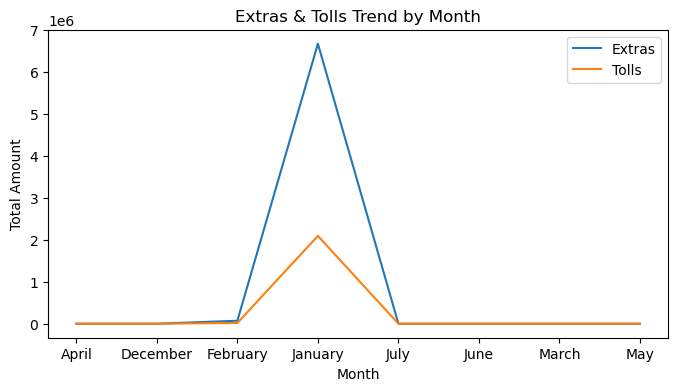

In [361]:
# Extras and tolls trend
plt.figure(figsize=(8,4))
sns.lineplot(x=extras_by_month.index, y=extras_by_month.values, label='Extras')
sns.lineplot(x=tolls_by_month.index, y=tolls_by_month.values, label='Tolls')
plt.title('Extras & Tolls Trend by Month')
plt.xlabel('Month')
plt.ylabel('Total Amount')
plt.legend()
plt.show()

In [365]:
#Do night-time trips receive higher tips?
# Define night hours (8 PM to 6 AM)
taxi_df['is_night'] = taxi_df['pickup_hour'].apply(lambda x: 1 if x >= 20 or x <= 6 else 0)

In [369]:
# Average tip amount for night vs day
night_vs_day_tips = taxi_df.groupby('is_night')['tip_amount'].mean()
night_vs_day_tips

is_night
0    2.169379
1    2.328034
Name: tip_amount, dtype: float64

In [373]:
#Are passengers tipping more during peak traffic hours (when congestion surcharge is applied)?
# Average tip when congestion surcharge > 0 vs = 0
tip_congestion = taxi_df.groupby('has_congestion')['tip_amount'].mean()
tip_congestion

has_congestion
False    2.640616
True     2.182921
Name: tip_amount, dtype: float64

In [386]:
#Do trips with high distance but low fare suggest underpricing or misreporting?
# Flag trips with distance > 10 miles but fare < 10 dollars
taxi_df['possible_underpricing'] = (taxi_df['trip_distance'] > 10) & (taxi_df['fare_amount'] < 10)
# Count of such trips
underpricing_count = taxi_df['possible_underpricing'].sum()
underpricing_count

491

In [391]:
taxi_df.to_csv('Taxi.csv',index=False)

MemoryError: Unable to allocate 5.29 MiB for an array with shape (13, 3333) and data type <U32